# **Convex Optimization Project 3**
Name: Reza Kahidi\
Student Number: 810101249

In [1]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

Data

In [2]:
### Data ###
# This data file consists of parameters for the flight simulator problem. Some
# of the parameters are inspired by the paper "Grant, P., & Haycock, B. (2008).
# Effect of jerk and acceleration on the perception of motion strength. Journal
# of Aircraft, 45(4), 1190–1197." It contains the following parameters:
"""
- h: time step (s)
- P_max: position limit (m)
- position: T-array of reference position (m)
"""

h = 0.1
P_max = 0.6
position = np.array(
    [
        0.0,
        0.03302791,
        0.12840479,
        0.3084541,
        0.5859962,
        0.96290951,
        1.42991972,
        1.9676406,
        2.54874986,
        3.14105557,
        3.71110918,
        4.22795958,
        4.66662684,
        5.01090576,
        5.25518468,
        5.3994636,
        5.44374253,
        5.38802145,
        5.23230037,
        4.9765793,
        4.62085822,
        4.16513714,
        3.60941606,
        2.95369499,
        2.19797391,
        1.34225283,
        0.38512884,
        -0.67744937,
        -1.85172678,
        -3.14544116,
        -4.56695465,
        -6.12431524,
        -7.82435349,
        -9.67191597,
        -11.66932126,
        -13.81609974,
        -16.10904632,
        -18.54258016,
        -21.10937096,
        -23.80116177,
    ]
)


Solving Problem

In [3]:

p_ref = position
T = len(p_ref)
v_ref = np.diff(p_ref) / h
a_ref = np.diff(v_ref) / h
j_ref = np.diff(a_ref) / h
j_ref = j_ref.reshape(37,1)

# Define variables
p = cp.Variable((T,1))
v = cp.diff(p)/h
a = cp.diff(v)/h
j = cp.diff(a)/h


obj = cp.sum_squares(j - j_ref)
constraints = [cp.norm(p, 'inf') <= P_max]

prob = cp.Problem(cp.Minimize(obj), constraints)
prob.solve()

print("Problem Status:", prob.status)
print(f"\nOptimal value =  {prob.value:0.3f}\n")
print("p* = ", p.value)
print("-------------------------------------------")
print("j* = ", j.value)



Problem Status: optimal

Optimal value =  731.285

p* =  [[ 0.59999599]
 [ 0.20413316]
 [-0.13178614]
 [-0.38517182]
 [-0.54240369]
 [-0.60000368]
 [-0.56457999]
 [-0.45151969]
 [-0.28300498]
 [-0.08513889]
 [ 0.11547566]
 [ 0.29529774]
 [ 0.4371301 ]
 [ 0.53273058]
 [ 0.58443876]
 [ 0.60000204]
 [ 0.58677183]
 [ 0.55151138]
 [ 0.50042037]
 [ 0.4391594 ]
 [ 0.37287442]
 [ 0.30622133]
 [ 0.24339042]
 [ 0.18813092]
 [ 0.14377544]
 [ 0.11326456]
 [ 0.09776836]
 [ 0.09546545]
 [ 0.10202222]
 [ 0.11131822]
 [ 0.11633906]
 [ 0.11013947]
 [ 0.08677105]
 [ 0.04207336]
 [-0.02575756]
 [-0.11588454]
 [-0.22485743]
 [-0.34694836]
 [-0.47475353]
 [-0.59999147]]
-------------------------------------------
j* =  [[ 22.59007035]
 [ 13.62019104]
 [  3.47808206]
 [ -6.60820661]
 [-15.38707499]
 [-22.18219944]
 [-26.10301999]
 [-26.60293667]
 [-23.54090952]
 [-17.19725858]
 [ -8.24217388]
 [  2.33960454]
 [  7.74738664]
 [  7.35140237]
 [  6.76326172]
 [  6.19968572]
 [  5.66058434]
 [  5.14595755]
 [  

Plot

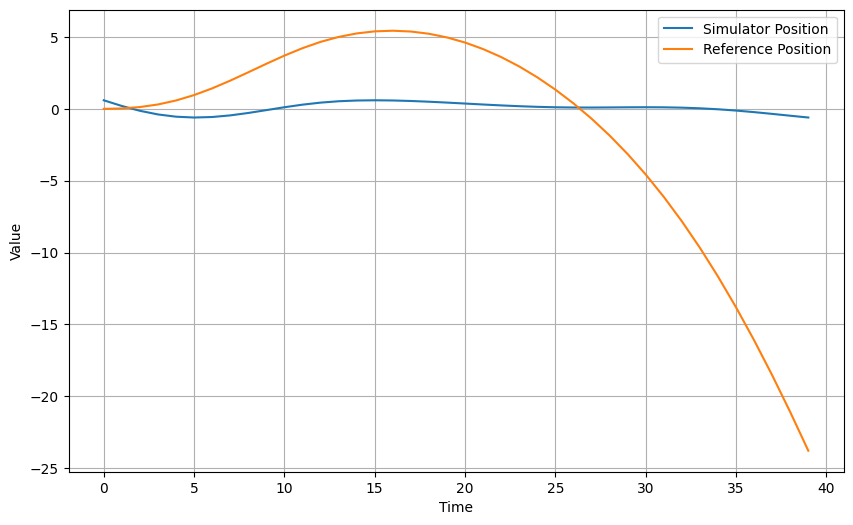

In [4]:
t = np.arange(T)
plt.figure(figsize=(10, 6))

plt.plot(t, p.value, label='Simulator Position')
plt.plot(t, p_ref, label='Reference Position')

# plt.plot(t[:-3], j.value, label='Simulator Jerk')
# plt.plot(t[:-3], j_ref, label='Reference Jerk')

plt.xlabel('Time')
plt.ylabel('Value')
plt.grid()
plt.legend()
plt.show()


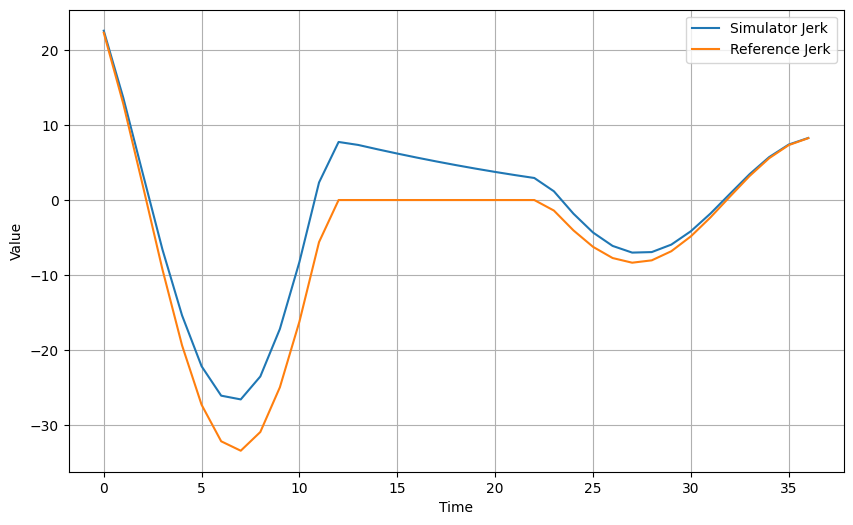

In [5]:
t = np.arange(T)
plt.figure(figsize=(10, 6))

plt.plot(t[:-3], j.value, label='Simulator Jerk')
plt.plot(t[:-3], j_ref, label='Reference Jerk')

plt.xlabel('Time')
plt.ylabel('Value')
plt.grid()
plt.legend()
plt.show()
